# NB07a · Corporate / Commercial Context

Builds a dong-level corporate density index (**Ec**) as supplementary demand context.
This is an enrichment layer — it does **not** modify constraint files.

**Ec** = weighted corporate density per km² (percentile-clipped, min-max normalised)

**Inputs:**
- `processed/seongnam_boundary.gpkg`
- `processed/admin_code_crosswalk.csv`
- `00_data/민간데이터/3. 법인 기업(cnt)-*/**/*.csv`
- Optional: `00_data/민간데이터/10. 매출(대민)(day)-*/**/*.csv` (sales proxy for merchant context)

**Outputs:**
- `processed/corporate_context_dong.csv`
- `processed/corporate_context_dong.gpkg`
- `processed/corporate_context_map.html` (optional)

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────
BASE  = Path('..').resolve()          # project root
PROC  = BASE / 'processed'
DATA  = BASE / '00_data' / '민간데이터'
OUT   = PROC

# ── Percentile clip ───────────────────────────────────────────────────
P_LO, P_HI = 1, 99

# ── Industry weights (delivery-demand relevance) ───────────────────────
# Keys are substrings of induty_pri_nm; str.contains() is used for matching
# so they survive the code-prefix format "G 도매 및 소매업(45~47)"
CORP_WEIGHT_KEYWORDS = {
    '운수 및 창고업':              3.0,
    '도매 및 소매업':              2.0,
    '숙박 및 음식점업':            1.5,
    '제조업':                      1.2,
    '전문, 과학 및 기술 서비스업': 1.0,
    '정보통신업':                  1.0,
    '금융 및 보험업':              0.8,
}
DEFAULT_WEIGHT = 0.5

print(f'BASE : {BASE}')
print(f'DATA : {DATA}')
print(f'OUT  : {OUT}')

BASE : C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset
DATA : C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\00_data\민간데이터
OUT  : C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed


## 1. Load Boundary & Compute area_km2

In [2]:
boundary = gpd.read_file(PROC / 'seongnam_boundary.gpkg', layer='dong')
print(f'Boundary: {len(boundary)} dongs  CRS={boundary.crs}')
print(f'Columns : {boundary.columns.tolist()}')

# Compute area in km² using Korean projected CRS
boundary_proj = boundary.to_crs('EPSG:5179')
boundary['area_km2'] = boundary_proj.geometry.area / 1e6

print(f'\narea_km2 range: {boundary["area_km2"].min():.2f} – {boundary["area_km2"].max():.2f} km²')
print(f'Total area   : {boundary["area_km2"].sum():.1f} km²')

crosswalk = pd.read_csv(PROC / 'admin_code_crosswalk.csv')
print(f'\nCrosswalk: {crosswalk.shape}  cols={crosswalk.columns.tolist()}')
crosswalk['CSV_ADMI_CD'] = crosswalk['CSV_ADMI_CD'].astype(str).str.zfill(8)

Boundary: 50 dongs  CRS=EPSG:4326
Columns : ['BASE_DATE', 'SHP_ADM_CD', 'ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'geometry']

area_km2 range: 0.27 – 17.57 km²
Total area   : 141.4 km²

Crosswalk: (50, 4)  cols=['SHP_ADM_CD', 'CSV_ADMI_CD', 'GU_NM', 'DONG_NM']


## 2. Load Corporate Data

In [3]:
corp_pattern = str(DATA / '3. 법인 기업(cnt)-*' / '3. 법인 기업(cnt)' / '*.csv')
corp_files   = sorted(glob.glob(corp_pattern))
print(f'Corporate files found: {len(corp_files)}')

if len(corp_files) == 0:
    raise FileNotFoundError(
        f'No corporate CSV files found under:\n  {corp_pattern}\n'
        'Check that 00_data/민간데이터/3. 법인 기업(cnt)-*/ is present.'
    )

print('Files (first 3):', [Path(f).name for f in corp_files[:3]])

def read_csv_robust(path):
    for enc in ('utf-8-sig', 'cp949'):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'Cannot decode: {path}')

dfs = []
for f in corp_files:
    try:
        dfs.append(read_csv_robust(f))
    except Exception as e:
        print(f'  SKIP {Path(f).name}: {e}')

corp = pd.concat(dfs, ignore_index=True)
print(f'\nLoaded: {len(corp):,} rows  columns: {corp.columns.tolist()}')
print(f'Date range (stdr_ym): {corp["stdr_ym"].min()} – {corp["stdr_ym"].max()}')
corp.head(3)

Corporate files found: 36
Files (first 3): ['gg_corp3_cnt_202301_성남시.csv', 'gg_corp3_cnt_202302_성남시.csv', 'gg_corp3_cnt_202303_성남시.csv']



Loaded: 70,380 rows  columns: ['stdr_ym', 'sido_nm', 'sigun_nm', 'admi_nm', 'induty_pri_cd', 'induty_pri_nm', 'induty_med_cd', 'induty_med_nm', 'vpap_comp_cn', 'kosdaq_comp_cn', 'konex_comp_cn', 'oc_comp_cn', 'co_ctx_comp_cn']
Date range (stdr_ym): 202301 – 202512


,stdr_ym,sido_nm,sigun_nm,admi_nm,induty_pri_cd,induty_pri_nm,induty_med_cd,induty_med_nm,vpap_comp_cn,kosdaq_comp_cn,konex_comp_cn,oc_comp_cn,co_ctx_comp_cn
0,202301,경기,성남시 분당구,구미1동,10A0000000,"A 농업, 임업 및 어업(01~03)",10A0100000,농업,0,0,0,0,2
1,202301,경기,성남시 분당구,구미1동,10A0000000,"A 농업, 임업 및 어업(01~03)",10A0200000,임업,0,0,0,0,5
2,202301,경기,성남시 분당구,구미1동,10B0000000,B 광업(05~08),10B0700000,비금속광물 광업; 연료용 제외,0,0,0,0,1


## 3. Industry Weight Mapping & Corporate Index

In [4]:
def assign_weight(industry_name: str) -> float:
    """Match industry name as substring of any CORP_WEIGHT_KEYWORDS key."""
    name = str(industry_name).strip()
    for keyword, weight in CORP_WEIGHT_KEYWORDS.items():
        if keyword in name:
            return weight
    return DEFAULT_WEIGHT

# Clean fields
corp['admi_nm']        = corp['admi_nm'].astype(str).str.strip()
corp['induty_pri_nm']  = corp['induty_pri_nm'].astype(str).str.strip()

# Total corporation count
count_cols = ['vpap_comp_cn', 'kosdaq_comp_cn', 'konex_comp_cn', 'oc_comp_cn', 'co_ctx_comp_cn']
for col in count_cols:
    corp[col] = pd.to_numeric(corp[col], errors='coerce').fillna(0)
corp['total_corp'] = corp[count_cols].sum(axis=1)

# Industry weight
corp['weight']        = corp['induty_pri_nm'].apply(assign_weight)
corp['weighted_corp'] = corp['total_corp'] * corp['weight']

print('Weight distribution (sample):')
print(corp.groupby('induty_pri_nm')['weight'].first().sort_values(ascending=False).head(10).to_string())
print(f'\nRows with weight > 1.0: {(corp["weight"] > 1.0).sum():,}')

Weight distribution (sample):
induty_pri_nm
H 운수 및 창고업(49~52)            3.0
운수 및 창고업(49~52)              3.0
G 도매 및 소매업(45~47)            2.0
도매 및 소매업(45~47)              2.0
I 숙박 및 음식점업(55~56)           1.5
숙박 및 음식점업(55~56)             1.5
C 제조업(10~34)                 1.2
제조업(10~34)                   1.2
M 전문, 과학 및 기술 서비스업(70~73)    1.0
정보통신업(58~63)                 1.0

Rows with weight > 1.0: 29,869


In [5]:
# ── Dong-level aggregation (average across all months) ─────────────────
ec_raw = (
    corp.groupby(['admi_nm', 'stdr_ym'])
    .agg(
        monthly_total_corp    = ('total_corp',    'sum'),
        monthly_weighted_corp = ('weighted_corp', 'sum'),
    )
    .reset_index()
)

ec_dong = (
    ec_raw.groupby('admi_nm')
    .agg(
        avg_total_corp    = ('monthly_total_corp',    'mean'),
        weighted_corp     = ('monthly_weighted_corp', 'mean'),
        month_count       = ('stdr_ym',               'nunique'),
    )
    .reset_index()
)

# Top industry per dong (across all records)
top_ind = (
    corp.groupby('admi_nm')['induty_pri_nm']
    .apply(lambda x: x.value_counts().index[0] if len(x) > 0 else '')
    .reset_index()
    .rename(columns={'induty_pri_nm': 'top_industry'})
)
ec_dong = ec_dong.merge(top_ind, on='admi_nm', how='left')

print(f'Dong-level rows: {len(ec_dong)}')
print(f'Month count range: {ec_dong["month_count"].min()} – {ec_dong["month_count"].max()}')
ec_dong.head(3)

Dong-level rows: 50
Month count range: 36 – 36


,admi_nm,avg_total_corp,weighted_corp,month_count,top_industry
0,고등동,528.888889,631.444444,36,C 제조업(10~34)
1,구미1동,1071.888889,1340.019444,36,C 제조업(10~34)
2,구미동,1008.166667,1173.641667,36,C 제조업(10~34)


## 4. Join to Boundary & Compute Ec

In [6]:
# Rename admi_nm → ADM_NM for join
ec_dong = ec_dong.rename(columns={'admi_nm': 'ADM_NM'})

# Build base output table from boundary
out_dong = boundary[['ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'area_km2', 'geometry']].copy()
out_dong = out_dong.merge(ec_dong, on='ADM_NM', how='left')

# Check merge success
n_matched = out_dong['avg_total_corp'].notna().sum()
n_total   = len(out_dong)
print(f'Merge: {n_matched}/{n_total} dongs matched ({n_matched/n_total:.0%})')

unmatched = out_dong[out_dong['avg_total_corp'].isna()]['ADM_NM'].tolist()
if unmatched:
    print(f'Unmatched boundary dongs: {unmatched}')
    corp_dongs = set(ec_dong['ADM_NM'])
    close = [d for d in unmatched if any(c in d for c in ['동', '구'])]
    print(f'Corporate dongs not in boundary: {sorted(corp_dongs - set(out_dong["ADM_NM"]))[:10]}')

Merge: 50/50 dongs matched (100%)


In [7]:
def clip_minmax(series: pd.Series, p_lo: int = P_LO, p_hi: int = P_HI) -> pd.Series:
    valid = series.dropna()
    if valid.empty:
        return pd.Series(0.5, index=series.index)
    lo, hi = valid.quantile(p_lo / 100), valid.quantile(p_hi / 100)
    rng = hi - lo
    if rng == 0:
        return pd.Series(0.5, index=series.index)
    return ((series.clip(lo, hi) - lo) / rng).fillna(0.0)

# Density columns
safe_area = out_dong['area_km2'].replace(0, np.nan)
out_dong['corporate_density_per_km2']         = out_dong['avg_total_corp']  / safe_area
out_dong['weighted_corp_density_per_km2']     = out_dong['weighted_corp']   / safe_area

# Ec = density-based, percentile-clipped normalisation
out_dong['Ec'] = clip_minmax(out_dong['weighted_corp_density_per_km2'])

# Fill unmatched with 0 and add note column
out_dong['corporate_context_note'] = np.where(
    out_dong['avg_total_corp'].isna(),
    'no corporate data matched',
    f'aggregated over {out_dong["month_count"].max():.0f} months'
)
out_dong[['avg_total_corp', 'weighted_corp',
           'corporate_density_per_km2', 'weighted_corp_density_per_km2', 'Ec']] = (
    out_dong[['avg_total_corp', 'weighted_corp',
               'corporate_density_per_km2', 'weighted_corp_density_per_km2', 'Ec']]
    .fillna(0.0)
)

print(f'Ec range: {out_dong["Ec"].min():.3f} – {out_dong["Ec"].max():.3f}')
print(f'Ec mean : {out_dong["Ec"].mean():.3f}')
out_dong[['ADM_NM', 'GU_NM', 'area_km2', 'avg_total_corp', 'Ec']].head(5)

Ec range: 0.000 – 1.000
Ec mean : 0.158


,ADM_NM,GU_NM,area_km2,avg_total_corp,Ec
0,신흥1동,수정구,0.322596,69.944444,0.116562
1,신흥2동,수정구,1.140283,173.500000,0.072189
2,신흥3동,수정구,0.321159,119.750000,0.218391
3,태평1동,수정구,1.341075,180.666667,0.058286
4,태평2동,수정구,0.482254,108.861111,0.113018


## 5. Optional: Sales Data as Merchant Proxy

In [8]:
# Delivery-related business categories (card sales data)
DELIVERY_CAT_L1 = {'음식', '소매/유통'}
DELIVERY_CAT_L2 = {
    '배달음식', '치킨', '피자/햄버거', '중식', '한식', '일식',
    '편의점', '슈퍼마켓', '대형마트', '제과/빵집', '음료/아이스크림'
}

sales_pattern = str(DATA / '10. 매출(대민)(day)-*' / '10. 매출(대민)(day)' / '*.csv')
sales_files   = sorted(glob.glob(sales_pattern))
print(f'Sales files found: {len(sales_files)}')

MERCHANT_AVAILABLE = len(sales_files) > 0

def _detect_sep(filepath):
    """Return | or , by peeking at the first header line."""
    with open(filepath, 'rb') as fh:
        header = fh.readline(300)
    return '|' if b'|' in header[:60] else ','

def _read_sales(filepath):
    """Read a sales CSV with auto separator and encoding fallback."""
    sep = _detect_sep(filepath)
    for enc in ('cp949', 'utf-8-sig', 'utf-8', 'euc-kr'):
        try:
            df = pd.read_csv(filepath, encoding=enc, sep=sep, low_memory=False)
            # Validate: must have admi_cty_no column
            if 'admi_cty_no' in df.columns:
                return df
        except Exception:
            pass
    return None

if MERCHANT_AVAILABLE:
    # Use all available files (not just last 12) for better coverage
    dfs_s = []
    skip_count = 0
    for f in sales_files:
        df_s = _read_sales(f)
        if df_s is not None:
            dfs_s.append(df_s)
        else:
            skip_count += 1
            print(f'  SKIP {Path(f).name}')
    print(f'  Loaded {len(dfs_s)}/{len(sales_files)} files  (skipped {skip_count})')
    if dfs_s:
        sales = pd.concat(dfs_s, ignore_index=True)
        print(f'Sales rows: {len(sales):,}  cols: {sales.columns.tolist()}')
        print(f'ta_ymd range: {sales["ta_ymd"].min()} – {sales["ta_ymd"].max()}')
        print(f'admi_cty_no sample: {sales["admi_cty_no"].dropna().head(3).tolist()}')
    else:
        print('No sales files could be loaded.')
        sales = None
else:
    print('No sales/merchant data found — merchant context will be NaN.')
    sales = None

Sales files found: 36


  Loaded 36/36 files  (skipped 0)


Sales rows: 87,265,541  cols: ['ta_ymd', 'cty_rgn_no', 'admi_cty_no', 'card_tpbuz_cd', 'card_tpbuz_nm_1', 'card_tpbuz_nm_2', 'hour', 'sex', 'age', 'day', 'amt', 'cnt']


ta_ymd range: 20230101 – 20251231


admi_cty_no sample: [41131510, 41131510, 41131510]


In [9]:
if MERCHANT_AVAILABLE and sales is not None:
    sales['admi_cty_no'] = sales['admi_cty_no'].astype(str).str.zfill(8)

    # Identify delivery-related rows
    is_delivery = (
        sales['card_tpbuz_nm_1'].isin(DELIVERY_CAT_L1) |
        sales['card_tpbuz_nm_2'].isin(DELIVERY_CAT_L2)
    )

    # Aggregate by dong code: count transactions (cnt) as proxy for merchant activity
    total_agg = (
        sales.groupby('admi_cty_no')['cnt']
        .sum()
        .rename('total_merchant_count')
        .reset_index()
    )
    del_agg = (
        sales[is_delivery].groupby('admi_cty_no')['cnt']
        .sum()
        .rename('delivery_related_merchant_count')
        .reset_index()
    )

    mer = total_agg.merge(del_agg, on='admi_cty_no', how='left')
    mer['delivery_related_merchant_count'] = mer['delivery_related_merchant_count'].fillna(0)
    mer['delivery_merchant_ratio'] = (
        mer['delivery_related_merchant_count'] / mer['total_merchant_count'].replace(0, 1)
    )

    # Normalise delivery merchant count → Od_merchant
    mer['Od_merchant'] = clip_minmax(mer['delivery_related_merchant_count'])

    # Join via crosswalk: CSV_ADMI_CD → ADM_NM
    mer = mer.merge(
        crosswalk[['CSV_ADMI_CD', 'DONG_NM', 'GU_NM']].rename(columns={'DONG_NM': 'ADM_NM'}),
        left_on='admi_cty_no', right_on='CSV_ADMI_CD', how='left'
    )

    mer_matched = mer['ADM_NM'].notna().sum()
    print(f'Merchant merge: {mer_matched}/{len(mer)} dong codes matched')

    # Merge into output table
    out_dong = out_dong.merge(
        mer[['ADM_NM', 'total_merchant_count', 'delivery_related_merchant_count',
             'delivery_merchant_ratio', 'Od_merchant']],
        on='ADM_NM', how='left'
    )
    print(f'\nTop 5 dongs by Od_merchant:')
    print(out_dong.nlargest(5, 'Od_merchant')[['ADM_NM', 'GU_NM', 'Od_merchant', 'delivery_merchant_ratio']].to_string(index=False))

else:
    # Sales data not available — add placeholder columns
    for col in ['total_merchant_count', 'delivery_related_merchant_count',
                'delivery_merchant_ratio', 'Od_merchant']:
        out_dong[col] = np.nan
    print('Merchant columns set to NaN (data not available).')

Merchant merge: 50/50 dong codes matched

Top 5 dongs by Od_merchant:
ADM_NM GU_NM  Od_merchant  delivery_merchant_ratio
  정자3동   분당구     1.000000                 0.909483
   삼평동   분당구     0.426463                 0.669573
  서현1동   분당구     0.364229                 0.216663
  수내1동   분당구     0.246410                 0.209015
  야탑1동   분당구     0.240598                 0.747518


## 6. Diagnostics

In [10]:
sep = '=' * 60
print(sep)
print('NB07a — Diagnostic Report')
print(sep)
print(f'Corporate files loaded : {len(corp_files)}')
print(f'Raw rows loaded        : {len(corp):,}')
print(f'Unique months          : {corp["stdr_ym"].nunique()}')
print(f'Unique dongs (corp)    : {corp["admi_nm"].nunique()}')
print(f'Boundary dongs         : {len(boundary)}')
print(f'Matched dongs          : {(out_dong["avg_total_corp"] > 0).sum()}')
print(f'Merchant data          : {"available (sales proxy)" if MERCHANT_AVAILABLE else "not available"}')
print()
print('Ec distribution:')
print(out_dong['Ec'].describe().round(3))
print()
print('Top 10 dongs by Ec:')
print(
    out_dong.nlargest(10, 'Ec')[
        ['ADM_NM', 'GU_NM', 'avg_total_corp', 'corporate_density_per_km2', 'Ec', 'top_industry']
    ].round(3).to_string(index=False)
)

NB07a — Diagnostic Report
Corporate files loaded : 36
Raw rows loaded        : 70,380
Unique months          : 36
Unique dongs (corp)    : 50
Boundary dongs         : 50
Matched dongs          : 50
Merchant data          : available (sales proxy)

Ec distribution:
count    50.000
mean      0.158
std       0.230
min       0.000
25%       0.029
50%       0.079
75%       0.158
max       1.000
Name: Ec, dtype: float64

Top 10 dongs by Ec:
ADM_NM GU_NM  avg_total_corp  corporate_density_per_km2    Ec top_industry
  수내1동   분당구        1732.639                   1695.803 1.000 C 제조업(10~34)
  정자1동   분당구        2098.000                   1441.158 0.887 C 제조업(10~34)
  야탑1동   분당구        1570.222                   1363.996 0.868 C 제조업(10~34)
   삼평동   분당구        3280.417                   1173.874 0.695 C 제조업(10~34)
 상대원2동   중원구         319.111                    621.054 0.402 C 제조업(10~34)
 상대원1동   중원구        3334.917                    491.451 0.314 C 제조업(10~34)
  야탑2동   분당구         275.750        

## 7. Save Outputs

In [11]:
# Output column order
out_cols_csv = [
    'ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'area_km2',
    'avg_total_corp', 'weighted_corp',
    'corporate_density_per_km2', 'weighted_corp_density_per_km2',
    'Ec', 'top_industry',
    'total_merchant_count', 'delivery_related_merchant_count',
    'delivery_merchant_ratio', 'Od_merchant',
    'corporate_context_note'
]

# CSV
out_path_csv = OUT / 'corporate_context_dong.csv'
out_dong[out_cols_csv].to_csv(out_path_csv, index=False, encoding='utf-8-sig')
print(f'corporate_context_dong.csv : {out_path_csv.stat().st_size // 1024} KB  ({len(out_dong)} rows)')

# GPKG (drop geometry-incompatible types before saving)
out_path_gpkg = OUT / 'corporate_context_dong.gpkg'
save_gdf = out_dong[out_cols_csv + ['geometry']].copy()
save_gdf['top_industry'] = save_gdf['top_industry'].astype(str)
save_gdf['corporate_context_note'] = save_gdf['corporate_context_note'].astype(str)
save_gdf.to_file(out_path_gpkg, layer='corporate_context_dong', driver='GPKG')
print(f'corporate_context_dong.gpkg: {out_path_gpkg.stat().st_size // 1024} KB')

print('\nOutput column schema:')
print(out_cols_csv)

corporate_context_dong.csv : 12 KB  (50 rows)


corporate_context_dong.gpkg: 484 KB

Output column schema:
['ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'area_km2', 'avg_total_corp', 'weighted_corp', 'corporate_density_per_km2', 'weighted_corp_density_per_km2', 'Ec', 'top_industry', 'total_merchant_count', 'delivery_related_merchant_count', 'delivery_merchant_ratio', 'Od_merchant', 'corporate_context_note']


## 8. Visualisations

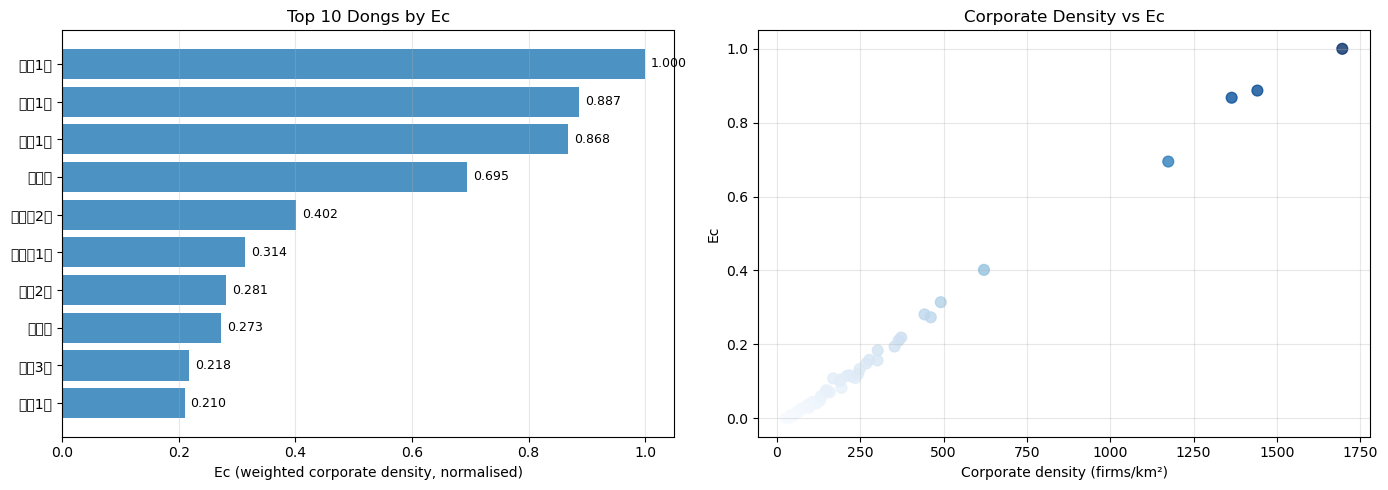

Saved corporate_context_chart.png


In [12]:
# ── Bar chart: Top 10 dongs by Ec ─────────────────────────────────────
top10 = out_dong.nlargest(10, 'Ec').copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Ec bar chart
ax = axes[0]
bars = ax.barh(top10['ADM_NM'][::-1], top10['Ec'][::-1], color='#2c7fb8', alpha=0.85)
ax.set_xlabel('Ec (weighted corporate density, normalised)')
ax.set_title('Top 10 Dongs by Ec')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, top10['Ec'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Right: Scatter corporate_density vs Ec
ax2 = axes[1]
ax2.scatter(out_dong['corporate_density_per_km2'], out_dong['Ec'],
            c=out_dong['Ec'], cmap='Blues', s=60, alpha=0.8)
ax2.set_xlabel('Corporate density (firms/km²)')
ax2.set_ylabel('Ec')
ax2.set_title('Corporate Density vs Ec')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'corporate_context_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved corporate_context_chart.png')

In [13]:
# ── Folium map: Ec by dong ─────────────────────────────────────────────
try:
    import folium
    import branca.colormap as cm

    city_centroid = out_dong.dissolve().to_crs('EPSG:5179').centroid.to_crs('EPSG:4326').iloc[0]
    center = [city_centroid.y, city_centroid.x]

    m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
    cmap = cm.LinearColormap(
        colors=['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494'],
        vmin=0, vmax=out_dong['Ec'].max(),
        caption='Corporate Context Index (Ec)'
    )

    folium.GeoJson(
        out_dong[['ADM_NM', 'GU_NM', 'Ec', 'avg_total_corp',
                  'corporate_density_per_km2', 'top_industry', 'geometry']].__geo_interface__,
        name='Ec by Dong',
        style_function=lambda f: {
            'fillColor': cmap(f['properties'].get('Ec') or 0),
            'color': '#555', 'weight': 1.2, 'fillOpacity': 0.75
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['ADM_NM', 'GU_NM', 'Ec', 'avg_total_corp', 'corporate_density_per_km2', 'top_industry'],
            aliases=['동명', '구명', 'Ec', '평균기업수', '기업밀도/km²', '주요업종'],
            localize=True
        )
    ).add_to(m)

    cmap.add_to(m)
    folium.LayerControl().add_to(m)

    out_html = OUT / 'corporate_context_map.html'
    m.save(out_html)
    print(f'Saved corporate_context_map.html ({out_html.stat().st_size // 1024} KB)')
    display(m)
except ImportError:
    print('folium not available — skipping HTML map')

Saved corporate_context_map.html (934 KB)


## 9. Final Summary

In [14]:
print('=' * 60)
print('NB07a — Final Summary')
print('=' * 60)
print(f'Output rows (dongs): {len(out_dong)}')
print()
print('Top 10 dongs by Ec:')
print(out_dong.nlargest(10, 'Ec')[['ADM_NM', 'GU_NM', 'Ec']].to_string(index=False))
print()
print('Null check (key columns):')
for col in ['Ec', 'ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'area_km2']:
    print(f'  {col}: {out_dong[col].isna().sum()} NaN')
print()
print('Output files:')
for f in ['corporate_context_dong.csv', 'corporate_context_dong.gpkg',
          'corporate_context_map.html', 'corporate_context_chart.png']:
    p = OUT / f
    s = f'{p.stat().st_size // 1024} KB' if p.exists() else 'not created'
    print(f'  {"OK" if p.exists() else "--"}  {f} ({s})')

NB07a — Final Summary
Output rows (dongs): 50

Top 10 dongs by Ec:
ADM_NM GU_NM       Ec
  수내1동   분당구 1.000000
  정자1동   분당구 0.886978
  야탑1동   분당구 0.867612
   삼평동   분당구 0.694841
 상대원2동   중원구 0.401635
 상대원1동   중원구 0.314149
  야탑2동   분당구 0.281131
   성남동   중원구 0.273290
  신흥3동   수정구 0.218391
  수진1동   수정구 0.210432

Null check (key columns):
  Ec: 0 NaN
  ADM_NM: 0 NaN
  GU_NM: 0 NaN
  CSV_ADMI_CD: 0 NaN
  area_km2: 0 NaN

Output files:
  OK  corporate_context_dong.csv (12 KB)
  OK  corporate_context_dong.gpkg (484 KB)
  OK  corporate_context_map.html (934 KB)
  OK  corporate_context_chart.png (74 KB)
